In [1]:
### Imports ###
from collections import defaultdict
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
from matplotlib import (
    pyplot as plt,
    rcParams,
    ticker as tkr,
    style,
    gridspec,
)
import numpy as np
import pandas as pd
from pandas.core.arrays.categorical import is_dict_like
import scipy
import seaborn as sns

In [2]:
N_COLORS = 10
COLORMAP = sns.color_palette("colorblind", N_COLORS)

# Common configurations for plottings
rcParams["figure.figsize"] = (3.2, 3.2)
rcParams["mathtext.fontset"] = "stix"
rcParams["font.family"] = "Times New Roman"
rcParams["text.usetex"] = True
rcParams["axes.spines.right"] = False   # Delete the right spine
rcParams["axes.spines.top"] = False     # Delete the top spine
rcParams["axes.grid"] = True            # Show grids in the plot
rcParams["grid.alpha"] = 0.2            # Adjust opacity of the grid
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"
rcParams["axes.linewidth"] = 1.0
rcParams["xtick.labelsize"] = 15
rcParams["ytick.labelsize"] = 15
rcParams["axes.labelsize"] = 17
rcParams["axes.titlesize"] = 17

MIN_MAX_RETURNS = {
    "acrobot-swingup": (0, 1000),
    "acrobot-swingup_sparse": (0, 1000),
    "ball_in_cup-catch": (0, 1000),
    "cartpole-balance": (0, 1000),
    "cartpole-balance_sparse": (0, 1000),
    "cartpole-swingup": (0, 1000),
    "cartpole-swingup_sparse": (0, 1000),
    "cartpole-two_poles": (0, 1000),
    "cartpole-three_poles": (0, 1000),
    "cheetah-run": (0, 1000),
    "finger-spin": (0, 1000),
    "finger-turn_easy": (0, 1000),
    "finger-turn_hard": (0, 1000),
    "fish-upright": (0, 1000),
    "fish-swim": (0, 1000),
    "hopper-stand": (0, 1000),
    "hopper-hop": (0, 1000),
    "lqr-lqr_2_1": (0, 1000),
    "lqr-lqr_6_2": (0, 1000),
    "manipulator-bring_ball": (0, 1000),
    "manipulator-bring_peg": (0, 1000),
    "manipulator-insert_ball": (0, 1000),
    "manipulator-insert_peg": (0, 1000),
    "pendulum-swingup": (0, 1000),
    "point_mass-easy": (0, 1000),
    "point_mass-hard": (0, 1000),
    "reacher-easy": (0, 1000),
    "reacher-hard": (0, 1000),
    "stacker-stack_2": (0, 1000),
    "stacker-stack_4": (0, 1000),
    "swimmer-swimmer6": (0, 1000),
    "swimmer-swimmer15": (0, 1000),
    "walker-stand": (0, 1000),
    "walker-walk": (0, 1000),
    "walker-run": (0, 1000),
    "dog-stand": (0, 1000),
    "dog-walk": (0, 1000),
    "dog-trot": (0, 1000),
    "dog-run": (0, 1000),
    "dog-fetch": (0, 1000),
    "humanoid-walk": (0, 1000),
    "humanoid-run": (0, 1000),
    "humanoid-run_pure_state": (0, 1000),
    "humanoid_CMU-stand": (0, 1000),
    "humanoid_CMU-walk": (0, 1000),
    "humanoid_CMU-run": (0, 1000),
    "humanoid-stand": (0, 1000),
    "quadruped-walk": (0, 1000),
    "quadruped-run": (0, 1000),
    "quadruped-escape": (0, 1000),
    "quadruped-fetch": (0, 1000),
    "Ant-v4": (-1235.0, 5557.0),
    "HalfCheetah-v4": (-652.0, 8718.0),
    "Hopper-v4": (0.0, 3632.0),
    "Humanoid-v4": (64.0, 8220.0),
    "HumanoidStandup-v4": (26654.0, 262063.0),
    "InvertedDoublePendulum-v4": (31.0, 9355.0),
    "InvertedPendulum-v4": (3.0, 1000.0),
    "Pusher-v4": (-313.0, -23.0),
    "Reacher-v4": (-99.0, -4.0),
    "Swimmer-v4": (-37.0, 352.0),
    "Walker2d-v4": (-14.0, 6192.0),
    "BattleZone": [-0.01, 1.47],
    "DoubleDunk": [-2.53, 9.68],
    "NameThisGame": [-0.29, 2.26],
    "Phoenix": [-0.11, 4.41],
    "Qbert": [-0.01, 1.37],
}

CONTINUOUS_CONTROL_ALGO = (
    "ppo",
    "sac",
    "tdmpc",
    "tdmpc2",
)

GYM_TASKS = (
    "Ant-v4",
    "HalfCheetah-v4",
    "Hopper-v4",
    "Humanoid-v4",
    "HumanoidStandup-v4",
    "InvertedDoublePendulum-v4",
    "InvertedPendulum-v4",
    "Pusher-v4",
    "Reacher-v4",
    "Swimmer-v4",
    "Walker2d-v4",
)

### RPH function

In [3]:
def rph(
    ax: mpl.axes.Axes,
    x: np.ndarray,
    data: np.ndarray,
    percent: float=90,
    color_idx: int=0,
    plot_all: bool=True,
) -> None:
    """
    Run-wise percentile highlighting.

    Args:
        ax (mpl.axes.Axes): Plot axis.
        x (np.ndarray): x-value of plot.
        data (np.ndarray): Array of learning curves.
        percent (float): Range of the center portion.
        color_idx (int): Index for specifying the color.
        plot_all (bool): Decide whether to plot all the learning curves or not.
    """
    data_mean = data.mean(axis=1)

    residual = 100 - percent
    low = residual / 2
    high = 100 - (residual / 2)

    percentile_values = np.percentile(data_mean, [low, 50, high], method="nearest")
    highlight_indices = [np.abs(data_mean - percentile_values[i]).argmin() for i in range(3)]

    for i in range(len(data_mean)):
        if not plot_all and i not in highlight_indices:
            continue
        ax.plot(
            x,
            data[i, :],
            alpha=0.7 if i in highlight_indices else 0.05,
            color=COLORMAP[color_idx],
            linestyle=':' if i in highlight_indices[::2] else '-',
            linewidth=2 if i in highlight_indices else 1,
        )

### Continuous control algorithm learning curves

[]

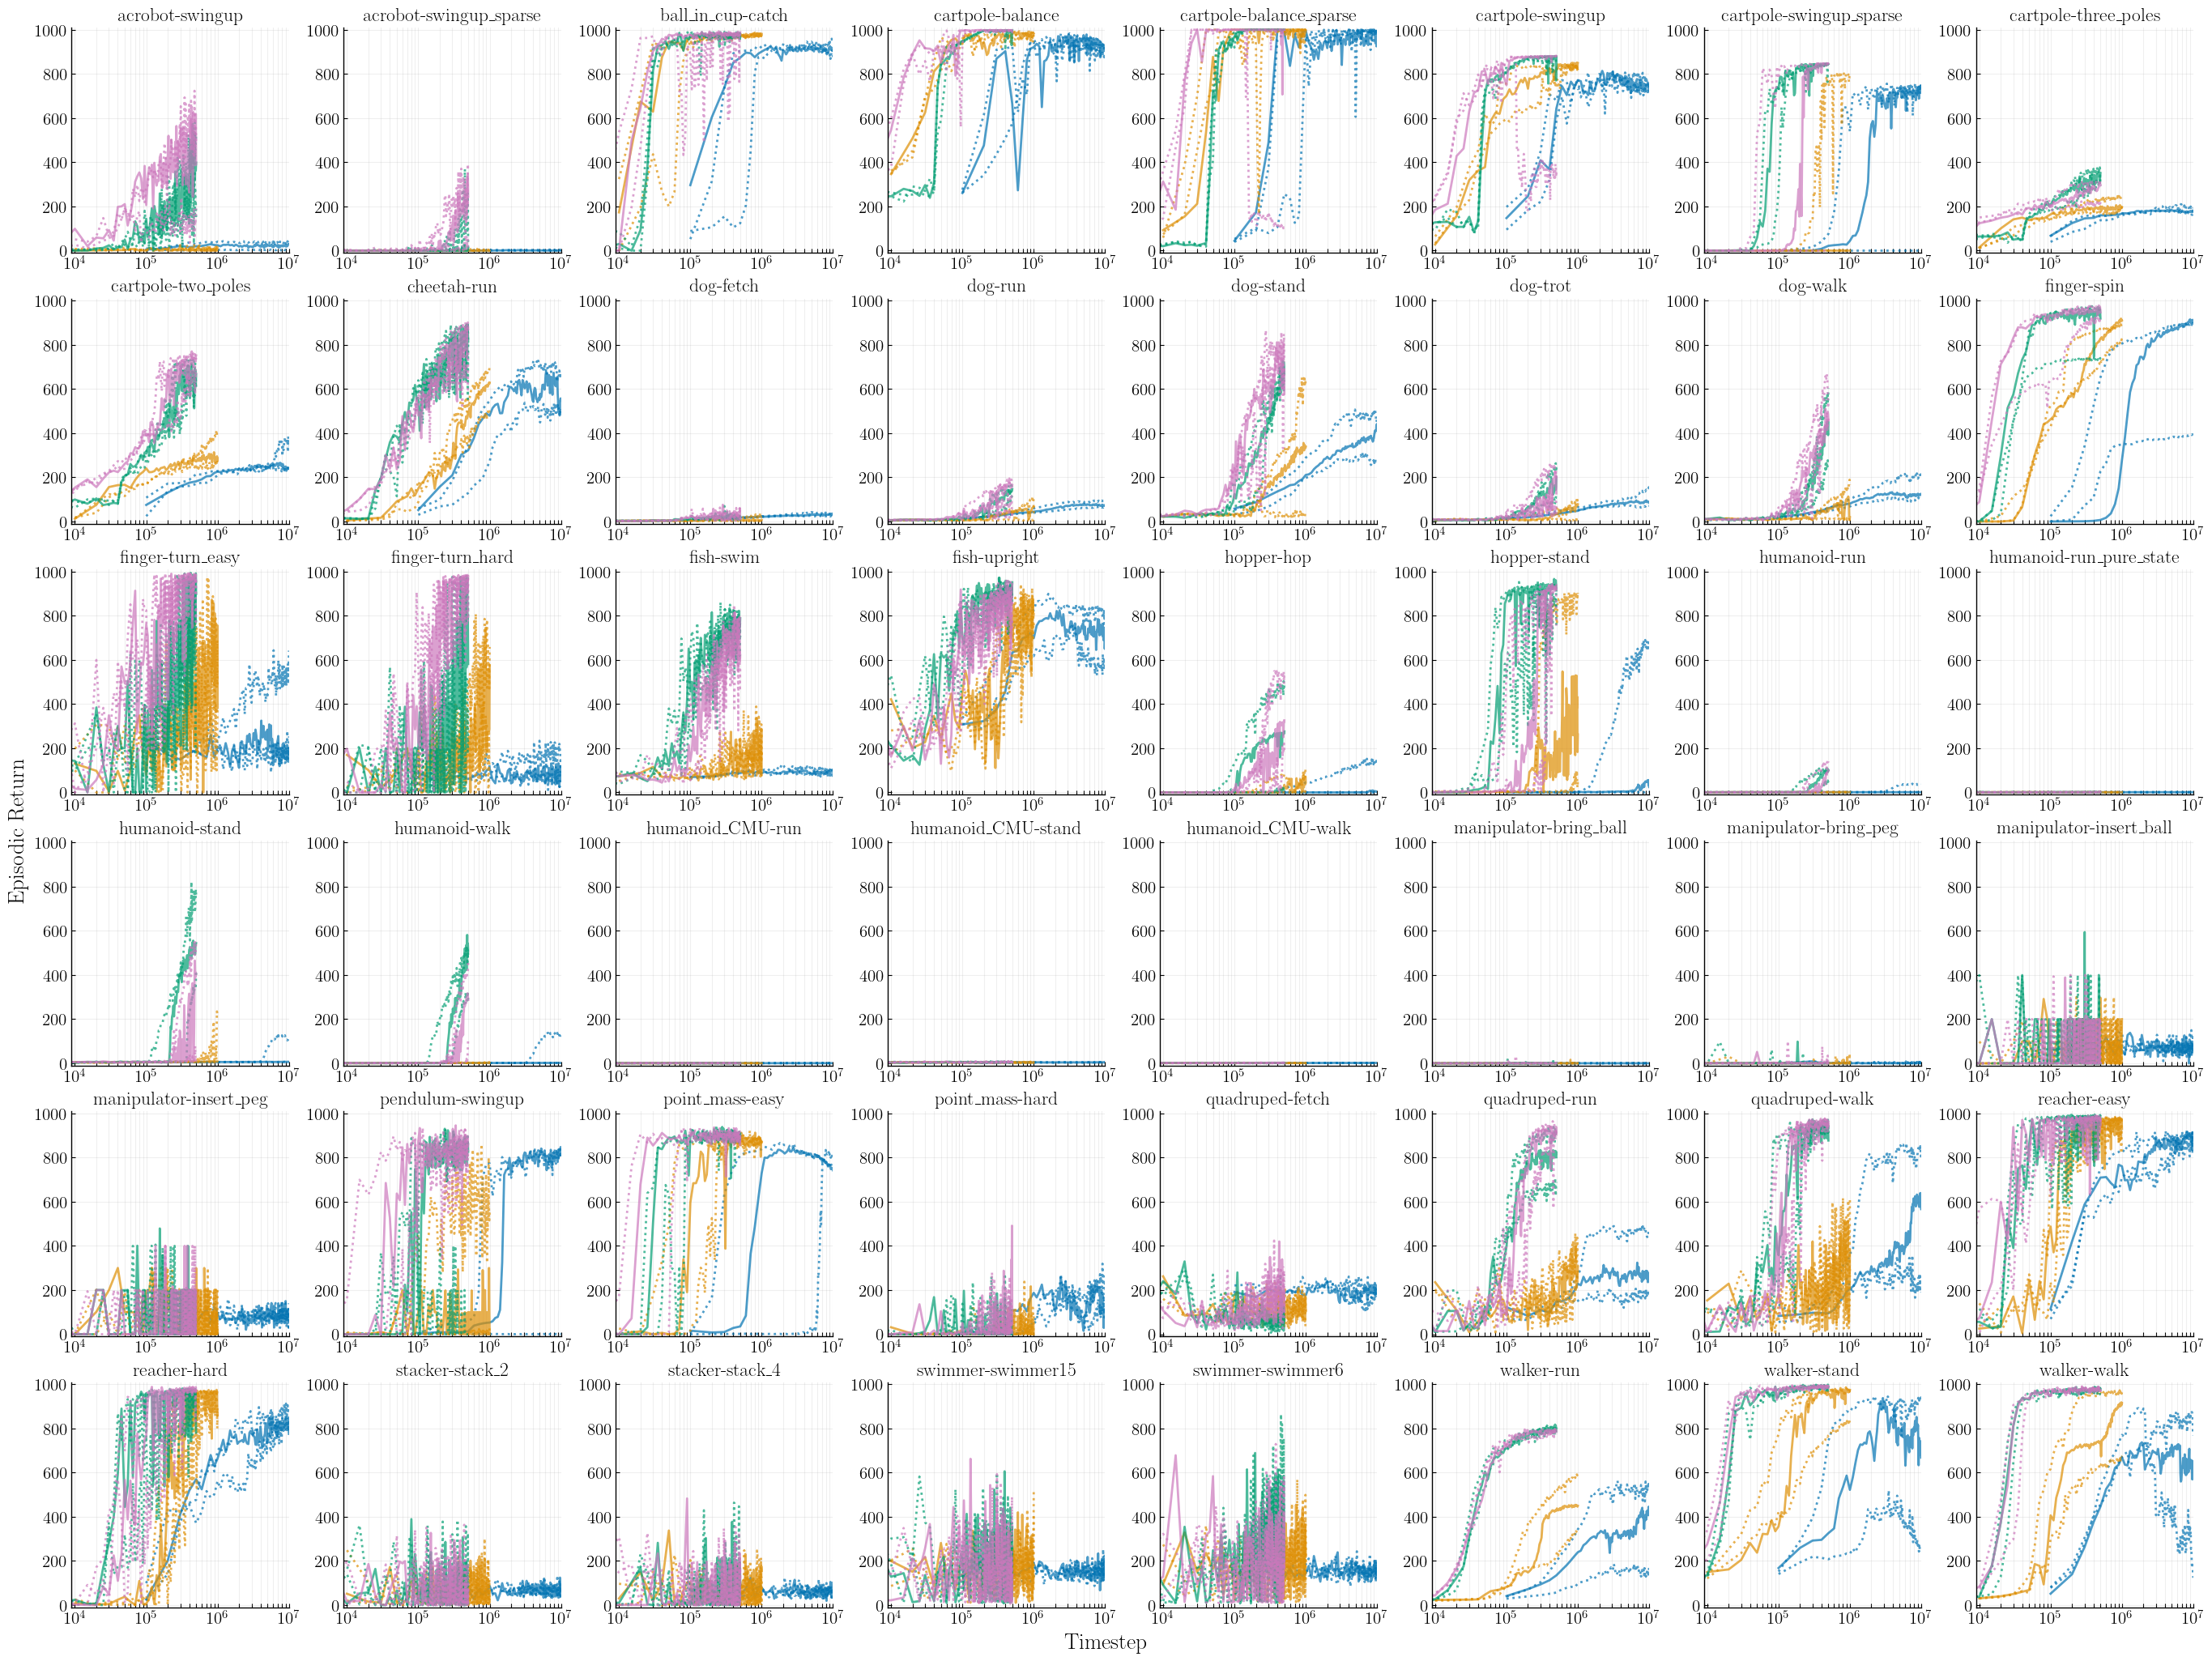

In [4]:
# RPH comparison of continuous control tasks
DATA_DIR = Path("../data")

algorithm_timesteps = {
    "ppo_default": np.arange(100_000, 10_000_001, 100_000),
    "sac_default": np.arange(10_000, 1_000_001, 10_000),
    "tdmpc": np.arange(5_000, 500_001, 5_000),
    "tdmpc2": np.arange(5_000, 500_001, 5_000),
}
algorithm_colors = {
    "ppo_default": 0,
    "sac_default": 1,
    "tdmpc": 2,
    "tdmpc2": 4,
}

nrows, ncols = 6, 8
fig, ax = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.4 * nrows), layout="constrained")
for i, algo in enumerate(algorithm_timesteps.keys()):
    data_file = DATA_DIR / f"{algo}.npz"
    data_dict = np.load(data_file)
    cnt = 0
    for task in sorted(list(data_dict.keys())):
        if task in GYM_TASKS:
            continue
        learning_curve = data_dict[task]
        r, c = cnt // ncols, cnt % ncols
        rph(ax[r, c], algorithm_timesteps[algo], learning_curve, color_idx=algorithm_colors[algo], plot_all=False)
        cnt += 1

        if i == 0:
            ax[r, c].set_title(task)
            ax[r, c].set_xlabel(None)
            ax[r, c].set_xlim(10**4 - 1000, 10**7 + 1000)
            ax[r, c].set_xscale("log")
            ax[r, c].xaxis.set_major_locator(tkr.LogLocator(numticks=999, subs="all"))
            ax[r, c].set_ylim(-10, 1010)

fig.supxlabel("Timestep", fontsize=20)
fig.supylabel("Episodic Return", fontsize=20)

plt.plot()

### Discrete control algorithm learning curves

[]

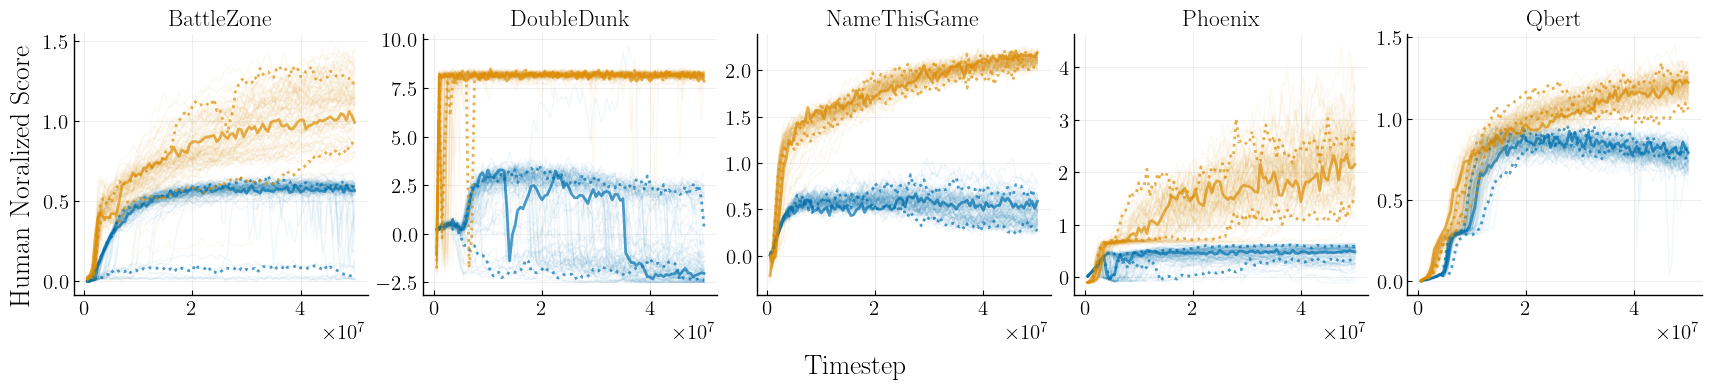

In [5]:
# RPH comparison of continuous control tasks
algorithm_timesteps = {
    "dqn": np.arange(500_000, 50_000_001, 500_000),
    "rainbow": np.arange(500_000, 50_000_001, 500_000),
}
algorithm_colors = {
    "dqn": 0,
    "rainbow": 1,
}

ncols = 5
fig, ax = plt.subplots(1, ncols, figsize=(3.4 * ncols, 3.4), layout="constrained")
for i, algo in enumerate(algorithm_timesteps.keys()):
    data_file = DATA_DIR / f"{algo}.npz"
    data_dict = np.load(data_file)
    cnt = 0
    for task in sorted(list(data_dict.keys())):
        learning_curve = data_dict[task]
        rph(ax[cnt], algorithm_timesteps[algo], learning_curve, color_idx=algorithm_colors[algo])

        if i == 0:
            ax[cnt].set_title(task)
        cnt += 1

fig.supxlabel("Timestep", y=-0.1, fontsize=20)
fig.supylabel("Human Noralized Score", fontsize=20)

plt.plot()